## Desicion Tree Assignment 11

## Tasks:
### 1. Data Preparation:
#### Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).

In [1]:
#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load a dataset
data= pd.read_excel("heart_disease.xlsx", sheet_name="Heart_disease")

# Display first 5 rows
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [3]:
data.shape

(908, 13)

In [4]:
#shape of dataset
data.shape

(908, 13)

### 2. Exploratory Data Analysis (EDA):
#### Perform exploratory data analysis to understand the structure of the dataset.

#### Check for missing values, outliers, and inconsistencies in the data.

In [5]:
#information dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
# Check missing values
data.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [7]:
# Fill missing values with mean
data['oldpeak'] = data['oldpeak'].fillna(data['oldpeak'].mean())

In [8]:
col = 'chol'  # Check Outlier

Q1 = data[col].quantile(0.25)
Q3 = data[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data[col] < lower) | (data[col] > upper)]

print("Outliers in", col, ":", len(outliers))

Outliers in chol : 187


In [9]:
data.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.055826,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.800000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


#### Visualize the distribution of features, including histograms, box plots, and correlation matrices

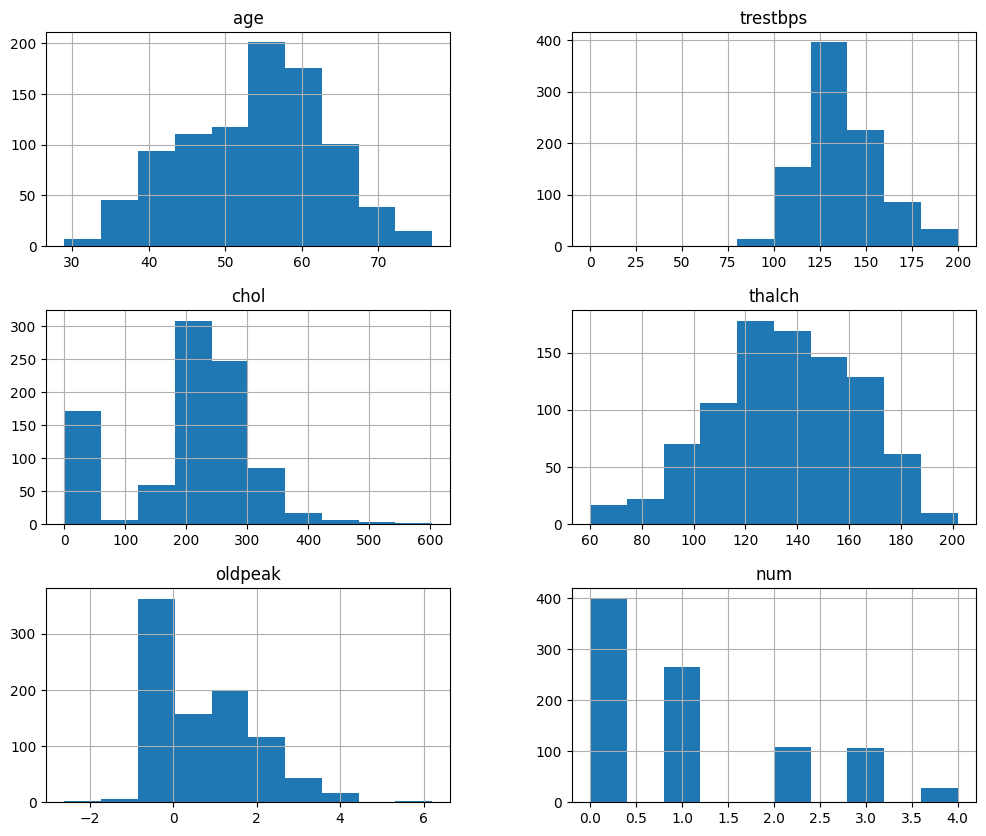

In [10]:
# Histogram
data.hist(figsize=(12,10))
plt.show()

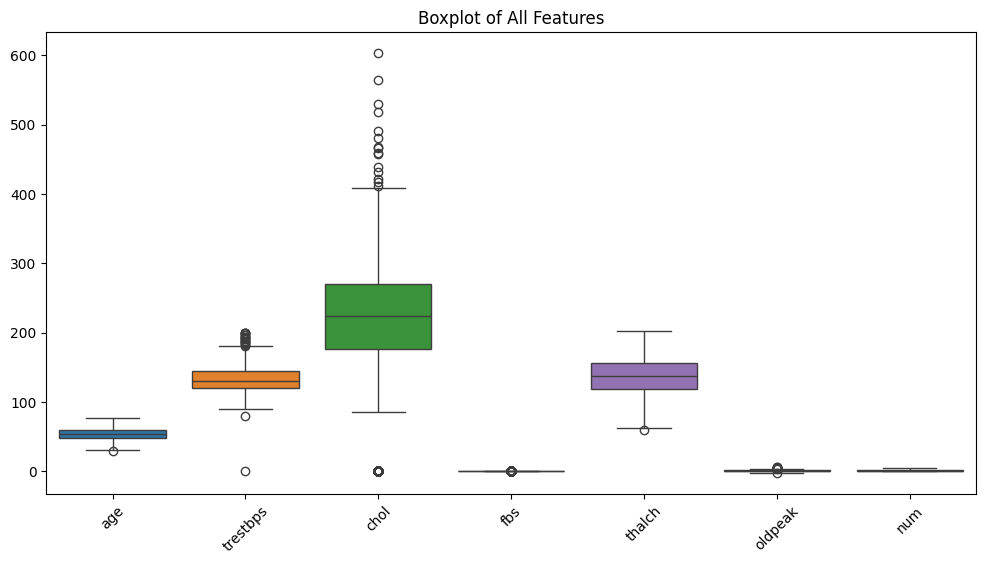

In [11]:
#Boxplot
plt.figure(figsize=(12,6))
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.title("Boxplot of All Features")
plt.show()

In [12]:
# Select numerical columns
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

# Remove outliers using IQR
for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]

# Check new shape
print(data.shape)

(692, 13)


In [13]:
#corr
corr=data.corr(numeric_only=True)
corr

,age,trestbps,chol,fbs,thalch,oldpeak,num
age,1.000000,0.254737,0.059555,0.212682,-0.327513,0.240866,0.353579
trestbps,0.254737,1.000000,0.140937,0.169737,-0.150773,0.173658,0.181656
chol,0.059555,0.140937,1.000000,0.033682,0.000300,0.038969,0.053955
fbs,0.212682,0.169737,0.033682,1.000000,-0.085802,0.035924,0.154427
thalch,-0.327513,-0.150773,0.000300,-0.085802,1.000000,-0.239153,-0.303033
oldpeak,0.240866,0.173658,0.038969,0.035924,-0.239153,1.000000,0.468784
num,0.353579,0.181656,0.053955,0.154427,-0.303033,0.468784,1.000000


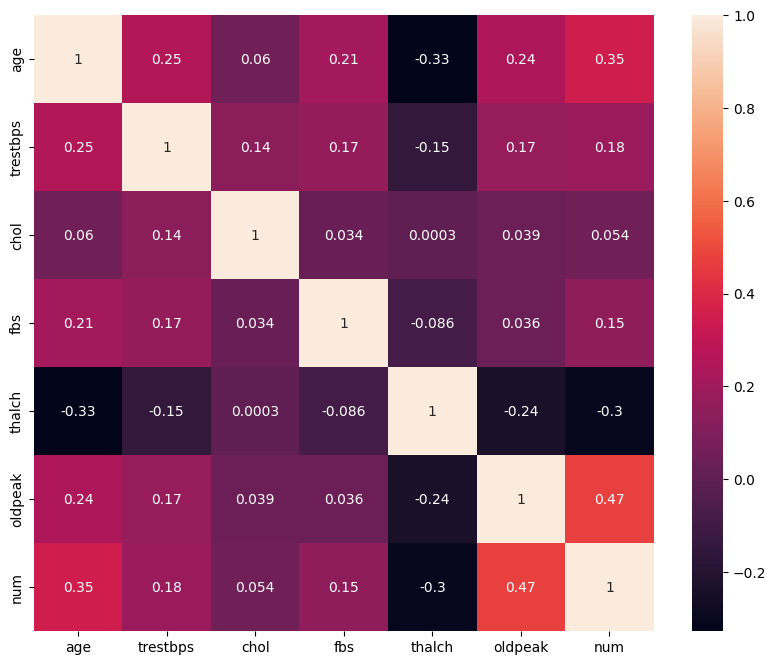

In [14]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show()

### 3. Feature Engineering:
#### If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.


In [15]:
#Encoding Categorical varible
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']

for col in categorical_cols:
    data[col] = data[col].astype(str)  
    data[col] = le.fit_transform(data[col])

In [16]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233,1,0,150,1,2.3,0,0,0
1,41,1,1,135,203,0,1,132,1,0.0,1,0,0
2,57,1,0,140,192,0,1,148,1,0.4,1,0,0
3,52,1,3,118,186,0,0,190,1,0.0,1,0,0
4,57,1,0,110,201,0,1,126,3,1.5,1,0,0


### 4. Decision Tree Classification:
#### Split the dataset into training and testing sets (e.g., using an 80-20 split).


In [17]:
X = data.drop('num', axis=1)   # Features
y = data['num']                # Target

In [18]:
y.unique()

array([0, 1, 2, 3, 4])

In [19]:
y = y.apply(lambda x: 1 if x > 0 else 0)
y.unique()

array([0, 1])

In [20]:
from sklearn.model_selection import train_test_split
#split train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#The dataset was split into training and testing sets using an 80-20 ratio.
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((553, 12), (139, 12), (553,), (139,))

#### Implement a Decision Tree Classification model using a library like scikit-learn.

In [21]:
from sklearn.tree import DecisionTreeClassifier

# Create model with hyperparameters
dtree = DecisionTreeClassifier(max_depth=6, 
                               criterion='entropy')
dtree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [22]:
yhat_train  = dtree.predict(X_train) #train predict
yhat_test = dtree.predict(X_test) #test predict

#### Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).


In [23]:
from sklearn.metrics import confusion_matrix, classification_report

In [24]:
# Train evaluation
cm_train = confusion_matrix(y_train,yhat_train)
cm_train

array([[258,  24],
       [ 45, 226]])

In [25]:
print(classification_report(y_train,yhat_train))

              precision    recall  f1-score   support

           0       0.85      0.91      0.88       282
           1       0.90      0.83      0.87       271

    accuracy                           0.88       553
   macro avg       0.88      0.87      0.87       553
weighted avg       0.88      0.88      0.87       553



In [26]:
#Test evaluation
cm_test = confusion_matrix(y_test,yhat_test)
cm_test

array([[62, 20],
       [13, 44]])

In [27]:
print(classification_report(y_test,yhat_test))

              precision    recall  f1-score   support

           0       0.83      0.76      0.79        82
           1       0.69      0.77      0.73        57

    accuracy                           0.76       139
   macro avg       0.76      0.76      0.76       139
weighted avg       0.77      0.76      0.76       139



### 5. Hyperparameter Tuning:
#### Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.


In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define parameters to test
params = {
    'max_depth': [3, 5, 6, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Create model
dt = DecisionTreeClassifier(random_state=42)

# Apply GridSearch
grid = GridSearchCV(dt, param_grid=params, cv=5)

# Train
grid.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


In [29]:
# Use best model
best_model = grid.best_estimator_

# Predict
y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7266187050359713


### 6. Model Evaluation and Analysis:


#### Analyse the performance of the Decision Tree model using the evaluation metrics obtained.

#### Visualize the decision tree structure to understand the rules learned by the model and identify important features

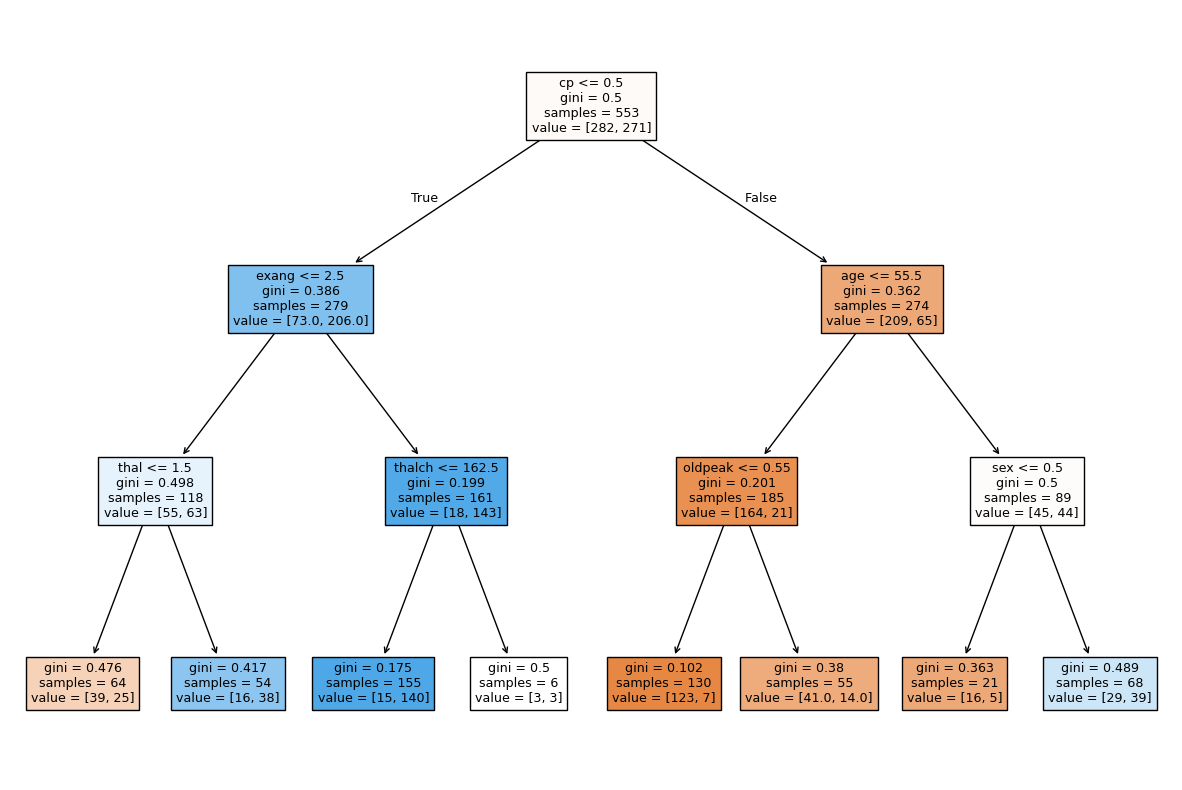

In [30]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot decision tree
plt.figure(figsize=(15,10))
plot_tree(best_model, filled=True, feature_names=X.columns)
plt.show()

In [31]:
# Get feature importance
importance = pd.Series(best_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

cp          0.586884
age         0.147364
exang       0.144503
thal        0.048532
sex         0.030520
oldpeak     0.026318
thalch      0.015878
trestbps    0.000000
restecg     0.000000
fbs         0.000000
chol        0.000000
slope       0.000000
dtype: float64

### Interview Questions:
#### 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

#### 2. What is the difference between the Label encoding and One-hot encoding?
